# Лабораторная работа №3

In [1]:
import pandas as pd
import sklearnex

from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

sklearnex.patch_sklearn()

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold

from sklearn.svm import LinearSVC
from sklearnex.svm import SVC
from sklearnex.neighbors import KNeighborsClassifier
import numpy as np
from sklearn.model_selection import cross_val_score
from imblearn.pipeline import Pipeline

import optuna
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, \
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

RANDOM_STATE = 13

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)
C:\Users\79585\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = pd.read_csv("datasets/neo.csv", index_col="Unnamed: 0")
data

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,-0.889019,-0.892421,0.316109,-1.612480,0.892109,0
1,-0.405274,-0.407831,-1.593181,-0.196165,0.406521,0
2,0.043918,0.042145,0.286110,1.266990,-0.044382,0
3,-0.750806,-0.753967,-0.258175,-1.094244,0.753369,0
4,0.734983,0.734416,0.777089,1.531822,-0.738079,0
...,...,...,...,...,...,...
90831,-0.819912,-0.823194,-0.982506,-1.585159,0.822739,0
90832,0.562217,0.561348,-0.921528,-0.158712,-0.564655,0
90833,-0.301614,-0.303991,2.706200,0.789522,0.302466,0
90834,-0.128848,-0.130923,-0.090366,-0.452655,0.129042,0


In [3]:
data["hazardous"].value_counts()

hazardous
0    81996
1     8840
Name: count, dtype: int64

Существует большой дисбаланс классов. Количество неопасных объектов гораздо больше количества опасных объектов.

Text(0, 0.5, 'counts')

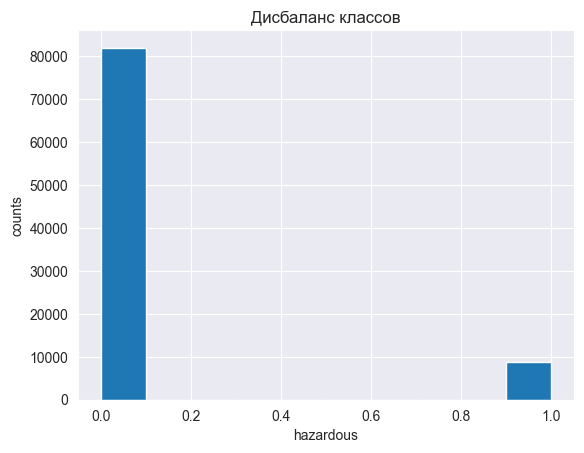

In [4]:
data["hazardous"].hist()
plt.title("Дисбаланс классов")
plt.xlabel("hazardous")
plt.ylabel("counts")

## Разделение выборки и балансировка классов

In [5]:
random_state = 13
X = data.drop("hazardous", axis=1)
y = data["hazardous"]

X_train, X_val_test, y_train, y_val_test = train_test_split(X, y, test_size=0.2, random_state = RANDOM_STATE, stratify=y)
X_test, X_val, y_test, y_val  = train_test_split(X_val_test, y_val_test, test_size=0.5, random_state = RANDOM_STATE, stratify=y_val_test)

print(f"Размер исходной выборки: {len(X)}\n"
      f"Размер тренировочной выборки: {len(X_train)}\n"
      f"Размер валидационной выборки: {len(X_val)}\n"
      f"Размер тестовой выборки: {len(X_test)}")

Размер исходной выборки: 90836
Размер тренировочной выборки: 72668
Размер валидационной выборки: 9084
Размер тестовой выборки: 9084


In [6]:
sm = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print(f"Размер сбалансированной выборки: {len(X_train_res)}")

Размер сбалансированной выборки: 131192


In [7]:
print("Доля классов в исходных данных:\n", y.value_counts(normalize=True))
print("\nДоля в тренировочной выборке:\n", y_train_res.value_counts(normalize=True))
print("\nДоля в валидационной выборке:\n", y_val.value_counts(normalize=True))
print("\nДоля в тестовой выборке:\n", y_test.value_counts(normalize=True))

Доля классов в исходных данных:
 hazardous
0    0.902682
1    0.097318
Name: proportion, dtype: float64

Доля в тренировочной выборке:
 hazardous
0    0.5
1    0.5
Name: proportion, dtype: float64

Доля в валидационной выборке:
 hazardous
0    0.902686
1    0.097314
Name: proportion, dtype: float64

Доля в тестовой выборке:
 hazardous
0    0.902686
1    0.097314
Name: proportion, dtype: float64


## Подготовка к обучению модели

In [8]:



def train_models_with_val(X_train, y_train, X_val, y_val, models_config):

    result={}

    for name, model_info in models_config.items():

        param_grid = model_info["param_grid"]
        model_class = model_info["model"]

        grid_search_model = GridSearchCV(
            param_grid=param_grid,
            estimator=model_class(),
            scoring="f1",
            cv=3
        )

        grid_search_model.fit(X_train, y_train)

        random_search_model = RandomizedSearchCV(
            param_distributions=param_grid,
            estimator=model_class(),
            scoring="f1",
            random_state=RANDOM_STATE,
            cv=3
        )

        random_search_model.fit(X_train, y_train)

        def objective(trial):
            trial_params = {}
            for p_name, p_values in param_grid.items():
                if isinstance(p_values[0], float):
                    trial_params[p_name] = trial.suggest_float(p_name, min(p_values), max(p_values), log=True)
                else:
                    trial_params[p_name] = trial.suggest_categorical(p_name, p_values)

            model = model_class(**trial_params)
            model.fit(X_train, y_train)
            score = f1_score(y_val, model.predict(X_val)) # максимизируем на валидационной выборке
            return score

        study = optuna.create_study(direction='maximize')
        study.optimize(objective, n_trials=15, show_progress_bar=False)

        optuna_model = model_class(**study.best_params)
        optuna_model.fit(X_train, y_train)

        result[name] = {}
        result[name]["GridSearch"] = {
            "model": grid_search_model.best_estimator_,
            "best_params": grid_search_model.best_params_
        }
        result[name]["RandomSearch"] = {
            "model": random_search_model.best_estimator_,
            "best_params": random_search_model.best_params_
        }
        result[name]["Optuna"] = {
            "model": optuna_model,
            "best_params": study.best_params
        }

    return result

In [9]:



def train_models_with_cross_val(X_train, y_train, models_config):

    result={}

    skf = StratifiedKFold(n_splits=10, random_state=RANDOM_STATE, shuffle=True)
    smote = SMOTE(random_state=RANDOM_STATE)



    for name, model_info in models_config.items():

        param_grid = model_info["param_grid"]
        model_obj = model_info["model"]
        prefixed_param_grid = {f"model__{k}": v for k, v in param_grid.items()}

        pipeline = Pipeline([('smote', smote), ('model', model_obj())])
        grid_search_model = GridSearchCV(
            param_grid=prefixed_param_grid,
            estimator= pipeline,
            scoring="f1",
            cv=skf
        )

        grid_search_model.fit(X_train, y_train)

        random_search_model = RandomizedSearchCV(
            param_distributions=prefixed_param_grid,
            estimator=pipeline,
            scoring="f1",
            random_state=RANDOM_STATE,
            cv=skf
        )

        random_search_model.fit(X_train, y_train)

        def objective(trial):
            trial_params = {}
            for p_name, p_values in param_grid.items():
                if isinstance(p_values[0], float):
                    trial_params[p_name] = trial.suggest_float(p_name, min(p_values), max(p_values), log=True)
                else:
                    trial_params[p_name] = trial.suggest_categorical(p_name, p_values)

            current_pipe = Pipeline([
                ('smote', smote),
                ('model', model_obj(**trial_params,random_state=RANDOM_STATE))
            ])

            score = cross_val_score(current_pipe, X_train, y_train, cv=skf, scoring='f1').mean()
            return score

        study = optuna.create_study(direction='maximize')
        study.optimize(objective, n_trials=5, show_progress_bar=False)

        final_optuna_pipe = Pipeline([
                ('smote', smote),
                ('model', model_obj(**study.best_params,random_state=RANDOM_STATE))
            ])
        final_optuna_pipe.fit(X_train, y_train)

        result[name] = {}
        result[name]["GridSearch"] = {
            "model": grid_search_model.best_estimator_,
            "best_params": grid_search_model.best_params_
        }
        result[name]["RandomSearch"] = {
            "model": random_search_model.best_estimator_,
            "best_params": random_search_model.best_params_
        }
        result[name]["Optuna"] = {
            "model": final_optuna_pipe,
            "best_params": study.best_params
        }

    return result

In [10]:
columns1 = []
columns2 = []

metrics = ["F1", "Accuracy", "Precision", "Recall"]
for type_of_data in ["Train Data", "Test Data"]:
    for metric in metrics:
        columns1.append(type_of_data + " " + metric)

for type_of_division in ["Метод hold-out", "Метод k-fold"]:
    for metric in metrics:
        columns2.append(type_of_division + " " + metric)

train_test_table = pd.DataFrame(columns=columns1)
hold_kfold_table = pd.DataFrame(columns=columns2)
train_test_table

,Train Data F1,Train Data Accuracy,Train Data Precision,Train Data Recall,Test Data F1,Test Data Accuracy,Test Data Precision,Test Data Recall


In [12]:
hold_kfold_table

,Метод hold-out F1,Метод hold-out Accuracy,Метод hold-out Precision,Метод hold-out Recall,Метод k-fold F1,Метод k-fold Accuracy,Метод k-fold Precision,Метод k-fold Recall


In [11]:
def get_metrics(y_test, y_predicted, print_results=False):
    names_of_metrics = ["F1", "Accuracy", "Precision", "Recall"]
    results = [
        round(f1_score(y_test, y_predicted), 2),
        round(accuracy_score(y_test, y_predicted), 4),
        round(precision_score(y_test, y_predicted), 4),
        round(recall_score(y_test, y_predicted), 4)
    ]

    if print_results:
        for name, result in zip(names_of_metrics, results):
            print(f"{name}: {result}")

    return results

In [12]:
def input_metrics_into_the_train_test_table(name_of_model,
                          predict_on_train_y, y_train,
                          predict_on_test_y, y_test):
    sk_learn_test_metrics = get_metrics(y_test, predict_on_test_y)

    sk_learn_train_metrics = get_metrics(y_train, predict_on_train_y)

    train_test_table.loc[name_of_model] = sk_learn_train_metrics + sk_learn_test_metrics

In [13]:
from sklearn.model_selection import cross_validate


def get_cv_report(model, X, y):
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
    scoring = ['accuracy', 'precision', 'recall', 'f1']
    cv_results = cross_validate(model, X, y, cv=skf, scoring=scoring)

    df = pd.DataFrame({
        'Accuracy': cv_results['test_accuracy'],
        'Prec.': cv_results['test_precision'],
        'Recall': cv_results['test_recall'],
        'F1': cv_results['test_f1']
    })

    stats = pd.DataFrame({
        'Accuracy': [df['Accuracy'].mean(), df['Accuracy'].std()],
        'Prec.': [df['Prec.'].mean(), df['Prec.'].std()],
        'Recall': [df['Recall'].mean(), df['Recall'].std()],
        'F1': [df['F1'].mean(), df['F1'].std()]
    }, index=['Mean', 'Std'])

    final_table = pd.concat([df, stats])

    return final_table.round(4)

## Обучение моделей

In [14]:


models_grid = {
    "Logistic regression":{
        "model": LogisticRegression,
        "param_grid":
            {
                "C": [0.1, 1, 10, 100],
                "penalty": ["l2"],
                "solver": ["lbfgs"]

            }
    },
    "KNN_euclidean":
        {
            "model": KNeighborsClassifier,
            "param_grid":{
                "n_neighbors": [3, 5, 11, 19],
                "weights": ["uniform", "distance"],
                "metric": ["euclidean"]
            }
        },
    "KNN_manhattan":{
            "model": KNeighborsClassifier,
            "param_grid":{
                "n_neighbors": [3, 5, 11, 19],
                "weights": ["uniform", "distance"],
                "metric": ["manhattan"]
            }
        },
    "KNN_chebyshev":{
        "model": KNeighborsClassifier,
            "param_grid":{
                "n_neighbors": [3, 5, 11, 19],
                "weights": ["uniform", "distance"],
                "metric": ["chebyshev"]
            }
    },

    "Naive_Bayes":{
        "model": GaussianNB,
        "param_grid":{
            "var_smoothing": np.logspace(-3, 1, num=20)
        }
    },

    "SVM_linear":{
        "model": LinearSVC,
        "param_grid":{
            "C": [0.1, 1, 10],
        }
    },
    "SVM_poly":{
        "model": SVC,
        "param_grid":{
            "C": [0.1, 1, 10],
            "gamma": ["scale"],
            "cache_size": [4000],
            "kernel": ["poly"],
            "degree": [2]
        }
    },

    "SVM_rbf":{
        "model": SVC,
        "param_grid":{
            "C": [0.1, 1, 10],
            "gamma": ["scale"],
            "kernel": ["rbf"],
            "cache_size": [4000],
        }
    },

     "SVM_sigmoid":{
        "model": SVC,
        "param_grid":{
            "C": [0.1, 1, 10],
            "gamma": ["scale"],
            "kernel": ["sigmoid"],
             "cache_size": [4000],
        }
    },
}

In [15]:
val_models = train_models_with_val(X_train_res, y_train_res, X_val, y_val, models_grid)

C:\Users\79585\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
[I 2026-04-04 15:42:52,062] A new study created in memory with name: no-name-0aac1322-b457-4e21-9625-ccdadb3298f0
[I 2026-04-04 15:42:52,164] Trial 0 finished with value: 0.4526912181303116 and parameters: {'C': 2.9614647330288024, 'penalty': 'l2', 'solver': 'lbfgs'}. Best is trial 0 with value: 0.4526912181303116.
[I 2026-04-04 15:42:52,266] Trial 1 finished with value: 0.4525630133106769 and parameters: {'C': 0.13750113153466934, 'penalty': 'l2', 'solver': 'lbfgs'}. Best is trial 0 with value: 0.4526912181303116.
[I 2026-04-04 15:42:52,368] Trial 2 finished with value: 0.4525630133106769 and parameters: {'C': 0.13153705568430027, 'penalty': 'l2', 'solver': 'lbfgs'}. Best is trial 0 with value: 0.4526912181303116.
[I 2026-

In [20]:
cross_val_models = train_models_with_cross_val(X_train, y_train, models_grid)

C:\Users\79585\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
[I 2026-04-04 16:41:02,470] A new study created in memory with name: no-name-b898e617-2622-4ed7-be28-43fae72e5005
[I 2026-04-04 16:41:03,649] Trial 0 finished with value: 0.45748750290980345 and parameters: {'C': 12.70959651009709, 'penalty': 'l2', 'solver': 'lbfgs'}. Best is trial 0 with value: 0.45748750290980345.
[I 2026-04-04 16:41:04,767] Trial 1 finished with value: 0.45748750290980345 and parameters: {'C': 22.091157345362454, 'penalty': 'l2', 'solver': 'lbfgs'}. Best is trial 0 with value: 0.45748750290980345.
[I 2026-04-04 16:41:06,015] Trial 2 finished with value: 0.45748834590727105 and parameters: {'C': 0.16141871220045184, 'penalty': 'l2', 'solver': 'lbfgs'}. Best is trial 2 with value: 0.45748834590727105.
[I 2

In [15]:
import pickle
with open("all_val_models_results.pkl", "rb") as file:
    val_models = pickle.load(file)

with open("all_cv_models_results.pkl", "rb") as file:
    cross_val_models = pickle.load(file)

In [19]:
for alg, search_info in val_models.items():
    for type_of_search, model_info in search_info.items():
        model = model_info["model"]
        y_test_predicted = model.predict(X_test)
        y_train_predicted = model.predict(X_train)

        name_of_model = f"{alg} with validation ({type_of_search})"
        
        input_metrics_into_the_train_test_table(name_of_model,
                              y_train_predicted, y_train,
                              y_test_predicted, y_test)
train_test_table

,Train Data F1,Train Data Accuracy,Train Data Precision,Train Data Recall,Test Data F1,Test Data Accuracy,Test Data Precision,Test Data Recall
Logistic regression with validation (GridSearch),0.46,0.7914,0.3061,0.9027,0.45,0.7917,0.3025,0.8733
Logistic regression with validation (RandomSearch),0.46,0.7914,0.3061,0.9027,0.45,0.7917,0.3025,0.8733
Logistic regression with validation (Optuna),0.46,0.7914,0.3061,0.9026,0.45,0.7917,0.3025,0.8733
KNN_euclidean with validation (GridSearch),1.00,1.0000,1.0000,1.0000,0.47,0.8591,0.3718,0.6493
KNN_euclidean with validation (RandomSearch),1.00,1.0000,1.0000,1.0000,0.47,0.8591,0.3718,0.6493
KNN_euclidean with validation (Optuna),1.00,1.0000,1.0000,1.0000,0.49,0.8343,0.3479,0.8032
KNN_manhattan with validation (GridSearch),1.00,1.0000,1.0000,1.0000,0.48,0.8646,0.3837,0.6459
KNN_manhattan with validation (RandomSearch),1.00,1.0000,1.0000,1.0000,0.48,0.8646,0.3837,0.6459
KNN_manhattan with validation (Optuna),1.00,1.0000,1.0000,1.0000,0.50,0.8296,0.3483,0.8620
KNN_chebyshev with validation (GridSearch),1.00,1.0000,1.0000,1.0000,0.46,0.8517,0.3572,0.6550


In [20]:
for alg, search_info in cross_val_models.items():
    for type_of_search, model_info in search_info.items():
        model = model_info["model"]
        y_test_predicted = model.predict(X_test)
        y_train_predicted = model.predict(X_train)

        name_of_model = f"{alg} with cross-validation ({type_of_search})"

        input_metrics_into_the_train_test_table(name_of_model,
                              y_train_predicted, y_train,
                              y_test_predicted, y_test)
train_test_table

,Train Data F1,Train Data Accuracy,Train Data Precision,Train Data Recall,Test Data F1,Test Data Accuracy,Test Data Precision,Test Data Recall
Logistic regression with validation (GridSearch),0.46,0.7914,0.3061,0.9027,0.45,0.7917,0.3025,0.8733
Logistic regression with validation (RandomSearch),0.46,0.7914,0.3061,0.9027,0.45,0.7917,0.3025,0.8733
Logistic regression with validation (Optuna),0.46,0.7914,0.3061,0.9026,0.45,0.7917,0.3025,0.8733
KNN_euclidean with validation (GridSearch),1.00,1.0000,1.0000,1.0000,0.47,0.8591,0.3718,0.6493
KNN_euclidean with validation (RandomSearch),1.00,1.0000,1.0000,1.0000,0.47,0.8591,0.3718,0.6493
KNN_euclidean with validation (Optuna),1.00,1.0000,1.0000,1.0000,0.49,0.8343,0.3479,0.8032
KNN_manhattan with validation (GridSearch),1.00,1.0000,1.0000,1.0000,0.48,0.8646,0.3837,0.6459
KNN_manhattan with validation (RandomSearch),1.00,1.0000,1.0000,1.0000,0.48,0.8646,0.3837,0.6459
KNN_manhattan with validation (Optuna),1.00,1.0000,1.0000,1.0000,0.50,0.8296,0.3483,0.8620
KNN_chebyshev with validation (GridSearch),1.00,1.0000,1.0000,1.0000,0.46,0.8517,0.3572,0.6550


In [21]:
train_test_table.sort_values(by="Test Data F1", ascending=False)

,Train Data F1,Train Data Accuracy,Train Data Precision,Train Data Recall,Test Data F1,Test Data Accuracy,Test Data Precision,Test Data Recall
KNN_manhattan with validation (Optuna),1.00,1.0000,1.0000,1.0000,0.50,0.8296,0.3483,0.8620
KNN_manhattan with cross-validation (Optuna),1.00,1.0000,1.0000,1.0000,0.50,0.8296,0.3483,0.8620
KNN_manhattan with cross-validation (GridSearch),1.00,1.0000,1.0000,1.0000,0.49,0.8400,0.3557,0.7930
KNN_manhattan with cross-validation (RandomSearch),1.00,1.0000,1.0000,1.0000,0.49,0.8400,0.3557,0.7930
KNN_euclidean with validation (Optuna),1.00,1.0000,1.0000,1.0000,0.49,0.8343,0.3479,0.8032
KNN_chebyshev with validation (Optuna),1.00,1.0000,1.0000,1.0000,0.48,0.8181,0.3322,0.8597
KNN_euclidean with cross-validation (Optuna),1.00,1.0000,1.0000,1.0000,0.48,0.8225,0.3379,0.8586
KNN_euclidean with cross-validation (RandomSearch),1.00,1.0000,1.0000,1.0000,0.48,0.8225,0.3379,0.8586
KNN_chebyshev with cross-validation (GridSearch),1.00,1.0000,1.0000,1.0000,0.48,0.8181,0.3322,0.8597
KNN_euclidean with cross-validation (GridSearch),1.00,1.0000,1.0000,1.0000,0.48,0.8225,0.3379,0.8586


Лучшей моделью оказалась KNN с манхеттенской метрикой, гиперпараметры который были получены при помощи кросс-валидации через фреймворк Optuna. Стоит отметить, что лучшими моделями по метрике F1 оказались модели KNN с любыми метриками расстояния (F1 принимает значение от 0.46 до 0.50).

Кроме KNN, хорошо себя показал алгоритм SVC с радиально-базисным ядром (для него метрика f1 принимает значение 0.46).

Прочие алгоритмы отработали примерно с тем же значением метрики: для наивной баейсовской модели, SVM с линейным ядром и логистической регрессии метрика f1 принимает значение 0.46.

Модели SVM с полиномиальным и сигмоидным ядрами отработали значительно хуже - для них метрика f1 принимает значение 0.25.

Стоит отметить, что модели, работающие на основе одних и тех же алгоритмов, при настройке гиперпараметров при помощи валидации и кросс-валидации дают практически одни и те же метрики (модель, полученная при помощи кросс-валидации, может иметь немного лучшие метрики, как например, наивная байесовская модель с Accuracy 0.7704 с кросс-валидацией и 0.7604 с валидационной выборкой). Это объясняется тем, что суть алгоритма кросс-валидации не предполагает фиксированного набора данных для обучения, так как данные делятся на фолды и модель последовательно обучается на каждом из них.

Заметим, что модели KNN на тренировочной выборке работают идеально, но при этом они значительно хуже работают на тестовой выборке.

На основе метрик выберем лучшие модели для каждого алгоритма. В дальнейшем будем рассматривать их.

In [16]:
knn_model = cross_val_models["KNN_manhattan"]["Optuna"]["model"]
svm_model = cross_val_models["SVM_rbf"]["Optuna"]["model"]
naive_bayes_model = cross_val_models["Naive_Bayes"]["Optuna"]["model"]
log_model = cross_val_models["Logistic regression"]["Optuna"]["model"]

In [17]:
knn_report = get_cv_report(knn_model, X_train_res, y_train_res)
knn_report

,Accuracy,Prec.,Recall,F1
0,0.9026,0.8402,0.9942,0.9108
1,0.9002,0.8367,0.9944,0.9087
2,0.9071,0.8451,0.9968,0.9147
3,0.9103,0.8504,0.9957,0.9173
4,0.9093,0.8500,0.9939,0.9164
5,0.9017,0.8381,0.9957,0.9101
6,0.9091,0.8490,0.9951,0.9163
7,0.9071,0.8455,0.9962,0.9147
8,0.9054,0.8433,0.9959,0.9133
9,0.9053,0.8439,0.9945,0.9130


In [18]:
smv_report = get_cv_report(svm_model, X_train_res, y_train_res)
smv_report

,Accuracy,Prec.,Recall,F1
0,0.8707,0.7963,0.9963,0.8852
1,0.8680,0.7937,0.9944,0.8828
2,0.8735,0.7996,0.9970,0.8874
3,0.8767,0.8047,0.9950,0.8898
4,0.8803,0.8092,0.9953,0.8927
5,0.8692,0.7944,0.9962,0.8839
6,0.8783,0.8058,0.9968,0.8912
7,0.8737,0.8005,0.9956,0.8874
8,0.8719,0.7975,0.9971,0.8862
9,0.8743,0.8013,0.9954,0.8879


In [19]:
naive_report = get_cv_report(naive_bayes_model, X_train_res, y_train_res)
naive_report

,Accuracy,Prec.,Recall,F1
0,0.8613,0.7904,0.9834,0.8764
1,0.8582,0.7887,0.9785,0.8734
2,0.8625,0.7933,0.9803,0.8770
3,0.8678,0.7991,0.9826,0.8814
4,0.8686,0.8028,0.9771,0.8814
5,0.8602,0.7896,0.9820,0.8754
6,0.8693,0.8010,0.9828,0.8826
7,0.8643,0.7964,0.9790,0.8783
8,0.8621,0.7922,0.9817,0.8768
9,0.8631,0.7947,0.9791,0.8773


In [20]:
log_report = get_cv_report(log_model, X_train_res, y_train_res)
log_report

,Accuracy,Prec.,Recall,F1
0,0.8398,0.7991,0.9078,0.8500
1,0.8357,0.7958,0.9030,0.8460
2,0.8440,0.8067,0.9049,0.8530
3,0.8419,0.8066,0.8995,0.8505
4,0.8482,0.8129,0.9047,0.8563
5,0.8402,0.7985,0.9100,0.8506
6,0.8455,0.8082,0.9059,0.8543
7,0.8420,0.8056,0.9015,0.8509
8,0.8365,0.8004,0.8966,0.8458
9,0.8414,0.8042,0.9026,0.8505


In [21]:
def extract_metrics(report_df):
    mean_vals = report_df.loc['Mean']
    std_vals = report_df.loc['Std']

    target_order = ['F1', 'Accuracy', 'Prec.', 'Recall']

    combined = {
        col: f"{mean_vals[col]:.4f} ± {std_vals[col]:.4f}"
        for col in target_order
    }

    return list(combined.values())

In [22]:
models_reports = {
    "KNN":{
        "model": knn_model,
        "report": knn_report
    },
    "SVM":{
        "model": svm_model,
        "report": smv_report
    },
    "Naive Bayes":{
        "model": naive_bayes_model,
        "report": naive_report
    },
    "Logistic regression":{
        "model": log_model,
        "report": log_report
    }
}

for alg_name, model_info in models_reports.items():
    model = model_info["model"]
    report = model_info["report"]

    predict = model.predict(X_train_res)

    hold_kfold_table.loc[alg_name] = get_metrics(y_train_res, predict) + extract_metrics(report)

hold_kfold_table

,Метод hold-out F1,Метод hold-out Accuracy,Метод hold-out Precision,Метод hold-out Recall,Метод k-fold F1,Метод k-fold Accuracy,Метод k-fold Precision,Метод k-fold Recall
KNN,1.00,1.0000,1.0000,1.0000,0.9135 ± 0.0029,0.9058 ± 0.0034,0.8442 ± 0.0048,0.9952 ± 0.0010
SVM,0.89,0.8739,0.8005,0.9960,0.8874 ± 0.0031,0.8737 ± 0.0039,0.8003 ± 0.0051,0.9959 ± 0.0009
Naive Bayes,0.88,0.8638,0.7948,0.9807,0.8780 ± 0.0030,0.8637 ± 0.0037,0.7948 ± 0.0049,0.9807 ± 0.0021
Logistic regression,0.85,0.8416,0.8038,0.9038,0.8508 ± 0.0033,0.8415 ± 0.0038,0.8038 ± 0.0052,0.9037 ± 0.0039


In [23]:
pd.DataFrame(data=log_model.named_steps["model"].coef_, columns=X_train.columns)

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude
0,1.190456,1.126992,0.239094,-0.317855,-0.042466


По коэффициентам для предикторов можем сказать, что чем быстрее и больше объект, тем вероятнее, что он опасен.

Кроме того, чем ближе объект, тем вероятнее, что он не опасен (т.к. коэффициент у признака `miss_distance` отрицательный)

## Визуализации

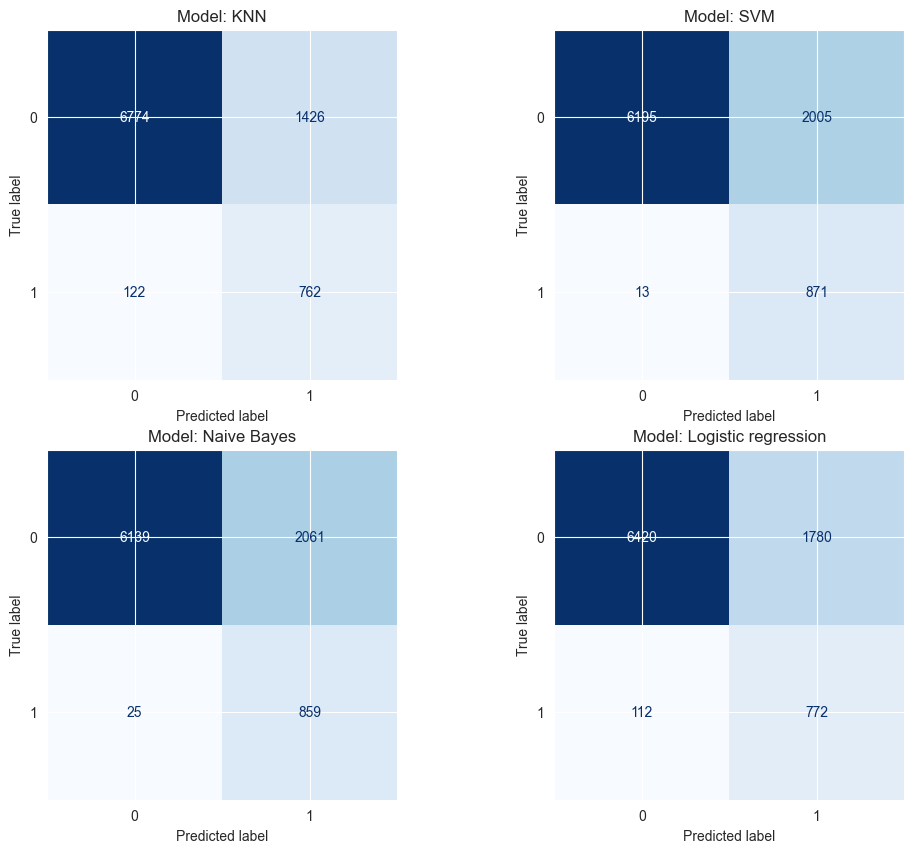

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes = axes.flatten()

for ax, (alg_name, model_info) in zip(axes, models_reports.items()):
    model = model_info["model"]
    report = model_info["report"]

    predict = model.predict(X_test)

    cm = confusion_matrix(y_test, predict)

    matrix = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

    matrix.plot(cmap="Blues", ax=ax, colorbar=False)

    ax.set_title(f"Model: {alg_name}")


Text(0.5, 1.0, 'Test')

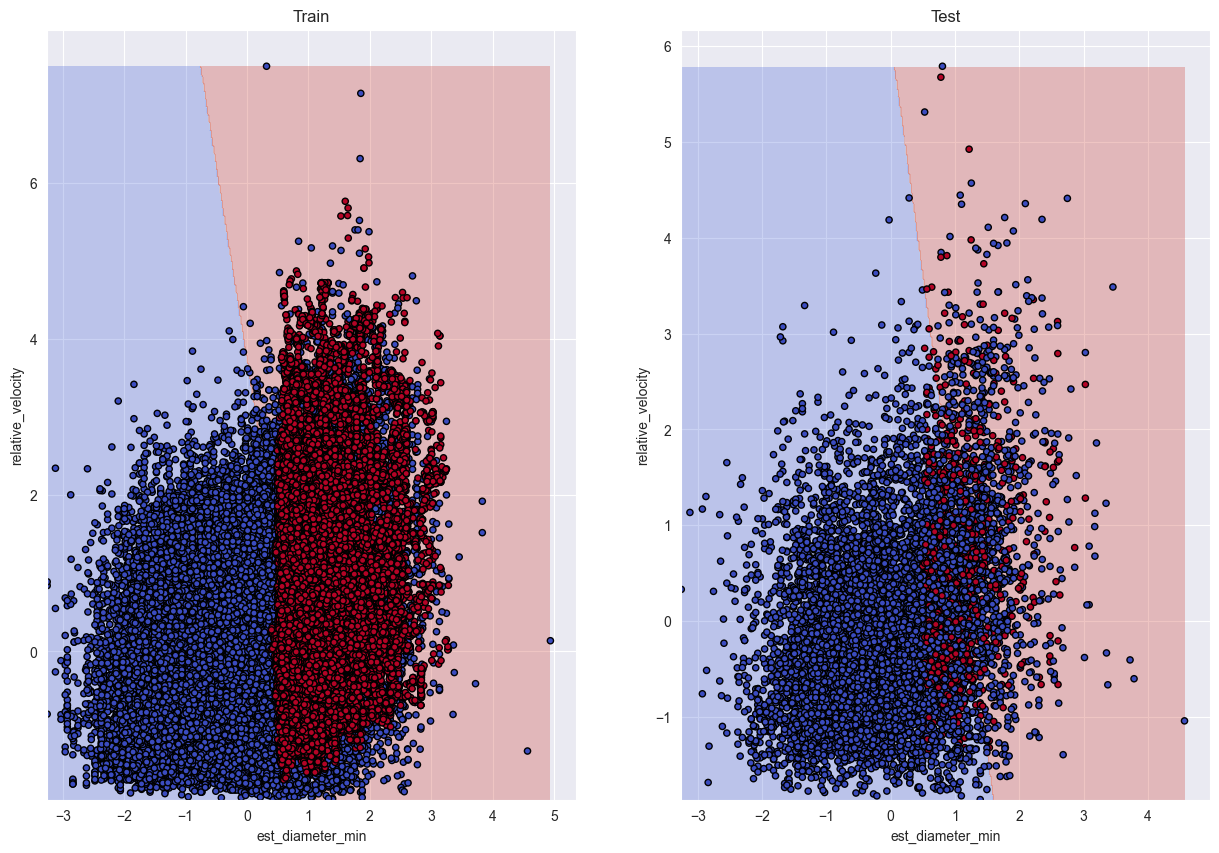

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10))

for ax, (X, y) in zip(axes, [(X_train_res, y_train_res), (X_test, y_test)]):

    feat_x = X["est_diameter_min"]
    feat_y = X["relative_velocity"]


    h = 0.02
    xx, yy = np.meshgrid(np.arange(feat_x.min(), feat_x.max(), h), np.arange(feat_y.min(), feat_y.max(), h))

    grid_data = pd.DataFrame(np.tile(X.mean().values, (len(xx.ravel()), 1)), columns=X_test.columns)

    grid_data["est_diameter_min"] = xx.ravel()
    grid_data["relative_velocity"] = yy.ravel()

    Z = log_model.predict(grid_data)
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.3)


    ax.scatter(feat_x, feat_y, c=y, edgecolors='k', cmap='coolwarm', s=20)
    ax.set_xlabel('est_diameter_min')
    ax.set_ylabel('relative_velocity')

axes[0].set_title("Train")
axes[1].set_title("Test")



Text(0.5, 0.98, 'SVM')

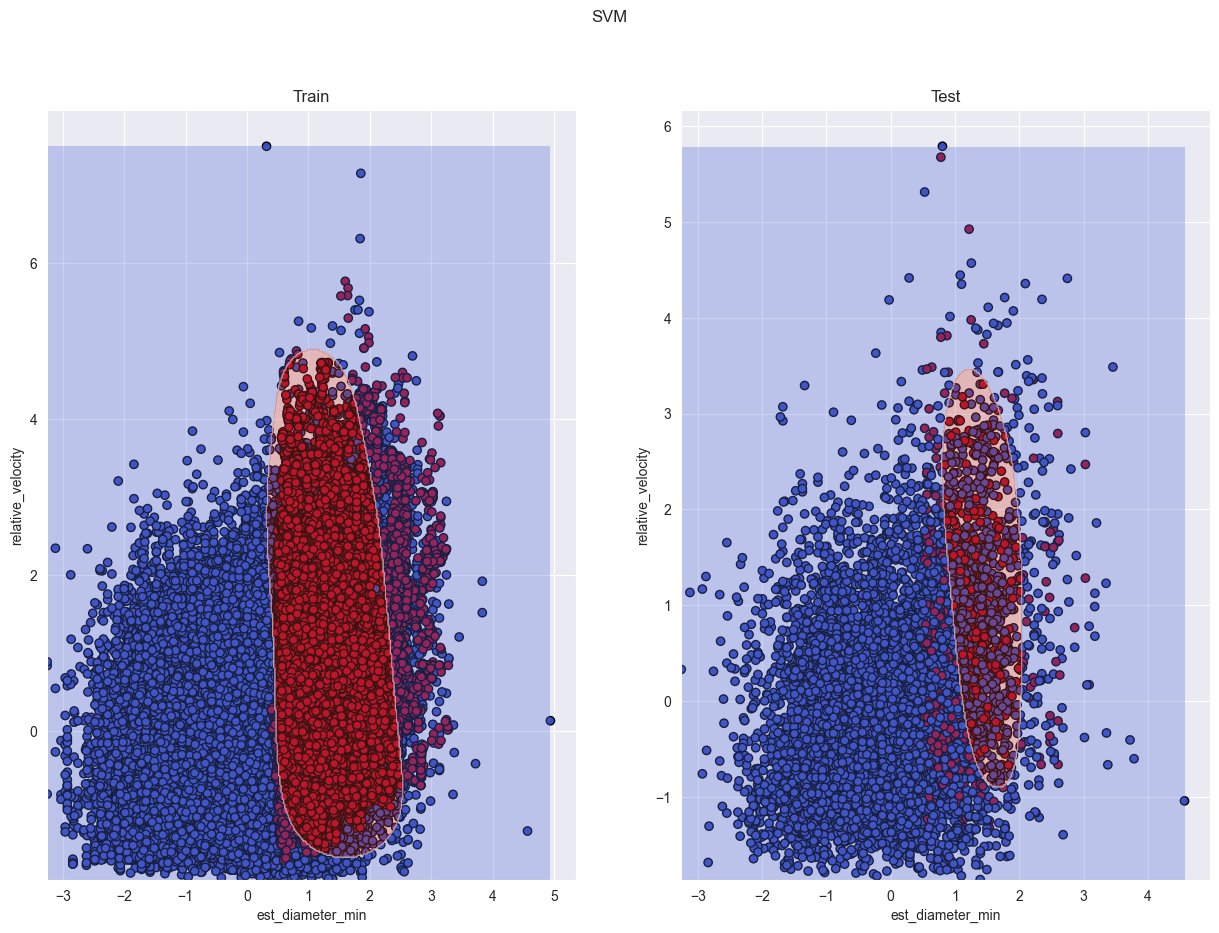

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10))

for ax, (X, y) in zip(axes, [(X_train_res, y_train_res), (X_test, y_test)]):

    feat_x = X["est_diameter_min"]
    feat_y = X["relative_velocity"]


    h = 0.02
    xx, yy = np.meshgrid(np.arange(feat_x.min(), feat_x.max(), h), np.arange(feat_y.min(), feat_y.max(), h))

    grid_data = pd.DataFrame(np.tile(X.mean().values, (len(xx.ravel()), 1)), columns=X_test.columns)

    grid_data["est_diameter_min"] = xx.ravel()
    grid_data["relative_velocity"] = yy.ravel()

    Z = svm_model.predict(grid_data)
    Z = Z.reshape(xx.shape)

    ax.scatter(feat_x, feat_y, c=y, edgecolors='k', cmap='coolwarm')
    ax.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.3)
    ax.set_xlabel('est_diameter_min')
    ax.set_ylabel('relative_velocity')

axes[0].set_title("Train")
axes[1].set_title("Test")

plt.suptitle("SVM")

In [68]:
models_reports

{'KNN': {'model': Pipeline(steps=[('smote', SMOTE(random_state=13)),
                  ('model',
                   KNeighborsClassifier(metric='manhattan', n_neighbors=19,
                                        weights='distance'))]),
  'report':       Accuracy   Prec.  Recall      F1
  0       0.9026  0.8402  0.9942  0.9108
  1       0.9002  0.8367  0.9944  0.9087
  2       0.9071  0.8451  0.9968  0.9147
  3       0.9103  0.8504  0.9957  0.9173
  4       0.9093  0.8500  0.9939  0.9164
  5       0.9017  0.8381  0.9957  0.9101
  6       0.9091  0.8490  0.9951  0.9163
  7       0.9071  0.8455  0.9962  0.9147
  8       0.9054  0.8433  0.9959  0.9133
  9       0.9053  0.8439  0.9945  0.9130
  Mean    0.9058  0.8442  0.9952  0.9135
  Std     0.0034  0.0048  0.0010  0.0029},
 'SVM': {'model': Pipeline(steps=[('smote', SMOTE(random_state=13)),
                  ('model', SVC(C=8.794346164734288, cache_size=4000))]),
  'report':       Accuracy   Prec.  Recall      F1
  0       0.8707  0.7963

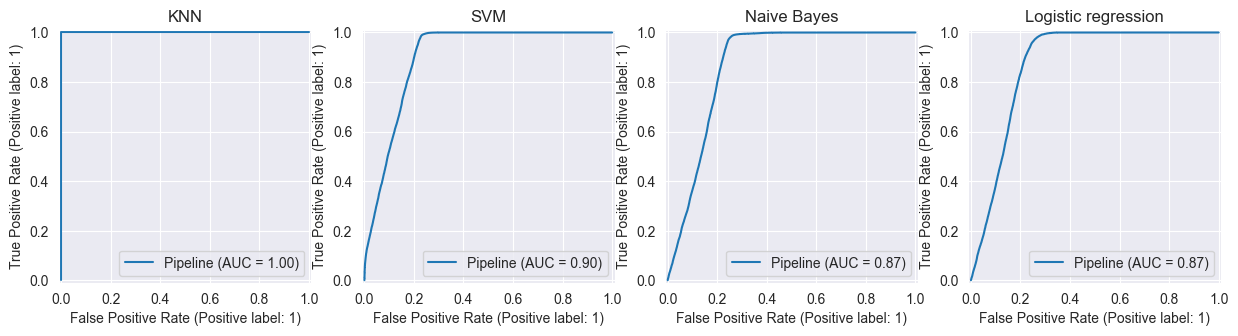

In [70]:
fix, axes = plt.subplots(1, 4, figsize=(15, 10))

for ax, (alg_name, model_info) in zip(axes, models_reports.items()):
    model = model_info["model"]
    RocCurveDisplay.from_estimator(model, X_train_res, y_train_res, ax=ax)
    ax.set_title(alg_name)

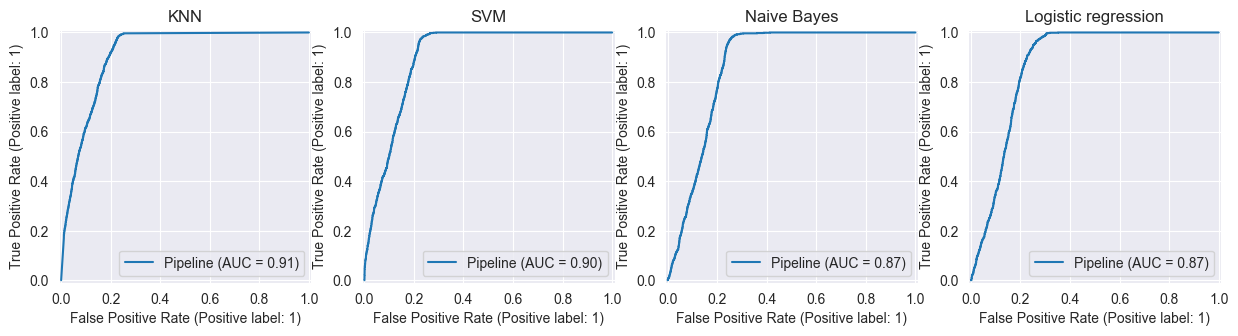

In [71]:
fix, axes = plt.subplots(1, 4, figsize=(15, 10))

for ax, (alg_name, model_info) in zip(axes, models_reports.items()):
    model = model_info["model"]
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax)
    ax.set_title(alg_name)